In [1]:
import sys
sys.path.append("../src")

In [2]:
from core.network import Network, servers_csv_to_dict, pings_csv_to_dict


network = Network.from_dicts(pings_csv_to_dict("data/datasets/pings.csv"), servers_csv_to_dict("data/datasets/servers.csv"), fraction = 1)

In [3]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Result:
    Stretches: list[float] 
    Guesses: list[bool]


### Inter-cluster Probability

In [6]:
# import cProfile
# import pstats
# profiler = cProfile.Profile()
# profiler.enable()

from core.simulator import Simulator
from core.gossip_algorithm import HierarchicalIntraCobraWalkInterBernoulliWithVoronoi
from core.attacker import create_random_attackers, UniformEstimator, LowestTimeEstimator

SAMPLE_SIZE = 20
sources = np.random.choice(network.nodes, SAMPLE_SIZE, replace=False)

InterProb = float

results: dict[InterProb, Result] = {}

probabilities = [0.4, 0.5, 0.6]

for prob in probabilities:
    print(f"Running simulation for Inter Cluster Probability = {prob}")

    simulator = Simulator(
        network=network,
        gossip_algorithm=HierarchicalIntraCobraWalkInterBernoulliWithVoronoi(
            network=network,
            inter_cluster_probability=prob,
            intra_cobra_walk_rho=0.8,
            fanout_inter=8,
            num_clusters=12,
            fanout_cobra=3,
        ),
    )

    stretches = []
    attacks = []

    all_nodes = [node.node_id for node in simulator.network.nodes]

    for source in sources:
        for i in range(5):
            simulator.setup(source)
            lst_attackers = create_random_attackers(
                LowestTimeEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            lst_attackers += create_random_attackers(
                UniformEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            stretch, attack = simulator.run(attackers=lst_attackers, msg_receival_limit=50)
            stretches += stretch.values
            attacks += attack.values

    results[prob] = Result(stretches, attacks)

# profiler.disable()
# stats = pstats.Stats(profiler)
# stats.strip_dirs().sort_stats("cumulative").print_stats(20)  # Change number to control output size

Running simulation for Inter Cluster Probability = 0.4
Running simulation for Inter Cluster Probability = 0.5
Running simulation for Inter Cluster Probability = 0.6


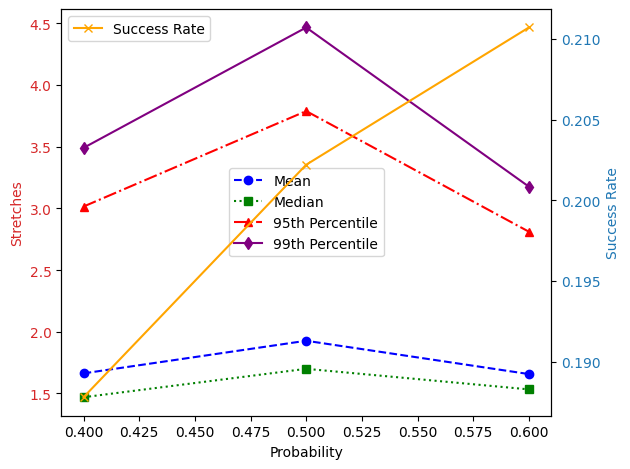

In [ ]:
import matplotlib.pyplot as plt

mean_values = []
median_values = []
percentile_90_values = []
percentile_99_values = []
success_rates = []

for prob in probabilities:
    stretches = np.array(results[prob].Stretches)

    # Compute IQR for outlier removal
    Q1 = np.percentile(stretches, 25)
    Q3 = np.percentile(stretches, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_stretches = stretches[(stretches >= lower_bound) & (stretches <= upper_bound)]

    mean_values.append(np.mean(filtered_stretches))
    median_values.append(np.median(filtered_stretches))
    percentile_90_values.append(np.percentile(filtered_stretches, 90))
    percentile_99_values.append(np.percentile(filtered_stretches, 99))
    success_rates.append(np.mean(results[prob].Guesses))

# Plot stretches on left y-axis and success rate on right y-axis
fig, ax1 = plt.subplots()

color = "tab:red"
ax1.set_xlabel("Probability")
ax1.set_ylabel("Stretches", color=color)
ax1.plot(probabilities, mean_values, marker='o', linestyle='dashed', label='Mean', color='blue')
ax1.plot(probabilities, median_values, marker='s', linestyle='dotted', label='Median', color='green')
ax1.plot(probabilities, percentile_90_values, marker='^', linestyle='dashdot', label='90th Percentile', color='red')
ax1.plot(probabilities, percentile_99_values, marker='d', linestyle='solid', label='99th Percentile', color='purple')
ax1.tick_params(axis="y", labelcolor=color)
ax1.legend()

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Success Rate", color=color)
ax2.plot(probabilities, success_rates, marker='x', linestyle='solid', label='Success Rate', color='orange')
ax2.tick_params(axis="y", labelcolor=color)
ax2.legend()

fig.tight_layout()
# plt.savefig("data/results/deepdive/inter_prob_vs_stretch_and_success_rate2.png")
plt.show()


### Intra-cluster Cobra-walk Rho

In [7]:
from core.simulator import Simulator
from core.gossip_algorithm import HierarchicalIntraCobraWalkInterBernoulliWithVoronoi
from core.attacker import create_random_attackers, UniformEstimator, LowestTimeEstimator

SAMPLE_SIZE = 100
sources = np.random.choice(network.nodes, SAMPLE_SIZE, replace=False)

InterProb = float

results: dict[InterProb, Result] = {}

rhos = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

for rho in rhos:
    print(f"Running simulation for Intra Cluster Cobra-walk Rho = {rho}")

    simulator = Simulator(
        network=network,
        gossip_algorithm=HierarchicalIntraCobraWalkInterBernoulliWithVoronoi(
            network=network,
            inter_cluster_probability=0.5,
            intra_cobra_walk_rho=rho,
            fanout_inter=8,
            num_clusters=10,
            fanout_cobra=2,
        ),
    )

    stretches = []
    attacks = []

    all_nodes = [node.node_id for node in simulator.network.nodes]

    for source in sources:
        for i in range(1):
            simulator.setup(source)
            lst_attackers = create_random_attackers(
                LowestTimeEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            lst_attackers += create_random_attackers(
                UniformEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            stretch, attack = simulator.run(attackers=lst_attackers, msg_receival_limit=100)
            stretches += stretch.values
            attacks += attack.values

    results[rho] = Result(stretches, attacks)

Running simulation for Intra Cluster Cobra-walk Rho = 0.0


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

mean_values = []
median_values = []
percentile_95_values = []
percentile_99_values = []
success_rates = []

for rho in rhos:
    stretches = np.array(results[rho].Stretches)

    # Compute IQR for outlier removal
    Q1 = np.percentile(stretches, 25)
    Q3 = np.percentile(stretches, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_stretches = stretches[(stretches >= lower_bound) & (stretches <= upper_bound)]

    mean_values.append(np.mean(filtered_stretches))
    median_values.append(np.median(filtered_stretches))
    percentile_95_values.append(np.percentile(filtered_stretches, 95))
    percentile_99_values.append(np.percentile(filtered_stretches, 99))
    success_rates.append(np.mean(results[rho].Guesses))

# Plot stretches on left y-axis and success rate on right y-axis
fig, ax1 = plt.subplots()

color = "tab:red"
ax1.set_xlabel("Probability")
ax1.set_ylabel("Stretches", color=color)
ax1.plot(rhos, mean_values, marker='o', linestyle='dashed', label='Mean', color='blue')
ax1.plot(rhos, median_values, marker='s', linestyle='dotted', label='Median', color='green')
ax1.plot(rhos, percentile_95_values, marker='^', linestyle='dashdot', label='95th Percentile', color='red')
ax1.plot(rhos, percentile_99_values, marker='d', linestyle='solid', label='99th Percentile', color='purple')
ax1.tick_params(axis="y", labelcolor=color)
ax1.legend()

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Success Rate", color=color)
ax2.plot(rhos, success_rates, marker='x', linestyle='solid', label='Success Rate', color='orange')
ax2.tick_params(axis="y", labelcolor=color)
ax2.legend()

fig.tight_layout()
# plt.savefig("data/results/deepdive/inter_prob_vs_stretch_and_success_rate2.png")
plt.show()


### Inter-cluster Fanout

In [ ]:
from core.simulator import Simulator
from core.gossip_algorithm import HierarchicalIntraCobraWalkInterBernoulliWithVoronoi
from core.attacker import create_random_attackers, UniformEstimator, LowestTimeEstimator

SAMPLE_SIZE = 100
sources = np.random.choice(network.nodes, SAMPLE_SIZE, replace=False)

InterProb = float

results: dict[InterProb, Result] = {}

fanouts = list(range(5,13))

for fanout in fanouts:
    print(f"Running simulation for Inter Cluster fanout = {fanout}")

    simulator = Simulator(
        network=network,
        gossip_algorithm=HierarchicalIntraCobraWalkInterBernoulliWithVoronoi(
            network=network,
            inter_cluster_probability=0.5,
            intra_cobra_walk_rho=0.5,
            fanout_inter=fanout,
            num_clusters=10,
            fanout_cobra=2,
        ),
    )

    stretches = []
    attacks = []

    all_nodes = [node.node_id for node in simulator.network.nodes]

    for source in sources:
        for i in range(1):
            simulator.setup(source)
            lst_attackers = create_random_attackers(
                LowestTimeEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            lst_attackers += create_random_attackers(
                UniformEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            stretch, attack = simulator.run(attackers=lst_attackers, msg_receival_limit=100)
            stretches += stretch.values
            attacks += attack.values

    results[fanout] = Result(stretches, attacks)

In [ ]:
import matplotlib.pyplot as plt

mean_values = []
median_values = []
percentile_95_values = []
percentile_99_values = []
success_rates = []

for fanout in fanouts:
    stretches = np.array(results[fanout].Stretches)

    # Compute IQR for outlier removal
    Q1 = np.percentile(stretches, 25)
    Q3 = np.percentile(stretches, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_stretches = stretches[(stretches >= lower_bound) & (stretches <= upper_bound)]

    mean_values.append(np.mean(filtered_stretches))
    median_values.append(np.median(filtered_stretches))
    percentile_95_values.append(np.percentile(filtered_stretches, 95))
    percentile_99_values.append(np.percentile(filtered_stretches, 99))
    success_rates.append(np.mean(results[rho].Guesses))

# Plot stretches on left y-axis and success rate on right y-axis
fig, ax1 = plt.subplots()

color = "tab:red"
ax1.set_xlabel("Probability")
ax1.set_ylabel("Stretches", color=color)
ax1.plot(fanouts, mean_values, marker='o', linestyle='dashed', label='Mean', color='blue')
ax1.plot(fanouts, median_values, marker='s', linestyle='dotted', label='Median', color='green')
ax1.plot(fanouts, percentile_95_values, marker='^', linestyle='dashdot', label='95th Percentile', color='red')
ax1.plot(fanouts, percentile_99_values, marker='d', linestyle='solid', label='99th Percentile', color='purple')
ax1.tick_params(axis="y", labelcolor=color)
ax1.legend()

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Success Rate", color=color)
ax2.plot(fanouts, success_rates, marker='x', linestyle='solid', label='Success Rate', color='orange')
ax2.tick_params(axis="y", labelcolor=color)
ax2.legend()

fig.tight_layout()
# plt.savefig("data/results/deepdive/inter_prob_vs_stretch_and_success_rate2.png")
plt.show()


### Cobra-walk branching factor

In [ ]:
from core.simulator import Simulator
from core.gossip_algorithm import HierarchicalIntraCobraWalkInterBernoulliWithVoronoi
from core.attacker import create_random_attackers, UniformEstimator, LowestTimeEstimator

SAMPLE_SIZE = 100
sources = np.random.choice(network.nodes, SAMPLE_SIZE, replace=False)

InterProb = float

results: dict[InterProb, Result] = {}

branches = list(range(2, 6))

for branching in branches:
    print(f"Running simulation for Intra Cluster Cobra-walk branching = {branching}")

    simulator = Simulator(
        network=network,
        gossip_algorithm=HierarchicalIntraCobraWalkInterBernoulliWithVoronoi(
            network=network,
            inter_cluster_probability=0.5,
            intra_cobra_walk_rho=0.5,
            fanout_inter=8,
            num_clusters=10,
            fanout_cobra=branching,
        ),
    )

    stretches = []
    attacks = []

    all_nodes = [node.node_id for node in simulator.network.nodes]

    for source in sources:
        for i in range(1):
            simulator.setup(source)
            lst_attackers = create_random_attackers(
                LowestTimeEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            lst_attackers += create_random_attackers(
                UniformEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            stretch, attack = simulator.run(attackers=lst_attackers, msg_receival_limit=100)
            stretches += stretch.values
            attacks += attack.values

    results[branching] = Result(stretches, attacks)

In [ ]:
import matplotlib.pyplot as plt

mean_values = []
median_values = []
percentile_95_values = []
percentile_99_values = []
success_rates = []

for branching in branches:
    stretches = np.array(results[branching].Stretches)

    # Compute IQR for outlier removal
    Q1 = np.percentile(stretches, 25)
    Q3 = np.percentile(stretches, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_stretches = stretches[(stretches >= lower_bound) & (stretches <= upper_bound)]

    mean_values.append(np.mean(filtered_stretches))
    median_values.append(np.median(filtered_stretches))
    percentile_95_values.append(np.percentile(filtered_stretches, 95))
    percentile_99_values.append(np.percentile(filtered_stretches, 99))
    success_rates.append(np.mean(results[branching].Guesses))

# Plot stretches on left y-axis and success rate on right y-axis
fig, ax1 = plt.subplots()

color = "tab:red"
ax1.set_xlabel("Probability")
ax1.set_ylabel("Stretches", color=color)
ax1.plot(branches, mean_values, marker='o', linestyle='dashed', label='Mean', color='blue')
ax1.plot(branches, median_values, marker='s', linestyle='dotted', label='Median', color='green')
ax1.plot(branches, percentile_95_values, marker='^', linestyle='dashdot', label='95th Percentile', color='red')
ax1.plot(branches, percentile_99_values, marker='d', linestyle='solid', label='99th Percentile', color='purple')
ax1.tick_params(axis="y", labelcolor=color)
ax1.legend()

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Success Rate", color=color)
ax2.plot(branches, success_rates, marker='x', linestyle='solid', label='Success Rate', color='orange')
ax2.tick_params(axis="y", labelcolor=color)
ax2.legend()

fig.tight_layout()
# plt.savefig("data/results/deepdive/inter_prob_vs_stretch_and_success_rate2.png")
plt.show()


### Number of clusters

In [5]:
from core.simulator import Simulator
from core.gossip_algorithm import HierarchicalIntraCobraWalkInterBernoulliWithVoronoi
from core.attacker import create_random_attackers, UniformEstimator, LowestTimeEstimator

SAMPLE_SIZE = 10
sources = np.random.choice(network.nodes, SAMPLE_SIZE, replace=False)

InterProb = float

results: dict[InterProb, Result] = {}

interval = list(range(2,15))

for number in interval:
    print(f"Running simulation for num. of clusters = {number}")

    simulator = Simulator(
        network=network,
        gossip_algorithm=HierarchicalIntraCobraWalkInterBernoulliWithVoronoi(
            network=network,
            inter_cluster_probability=0.5,
            intra_cobra_walk_rho=0.5,
            fanout_inter=8,
            num_clusters=number,
            fanout_cobra=2,
        ),
    )

    stretches = []
    attacks = []

    all_nodes = [node.node_id for node in simulator.network.nodes]

    for source in sources:
        for i in range(20):
            simulator.setup(source)
            lst_attackers = create_random_attackers(
                LowestTimeEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            lst_attackers += create_random_attackers(
                UniformEstimator,
                all_nodes,
                simulator.first_source.node_id,
                0.1,
                num_attackers=50,
            )
            stretch, attack = simulator.run(attackers=lst_attackers, msg_receival_limit=100)
            stretches += stretch.values
            attacks += attack.values

    results[number] = Result(stretches, attacks)

Running simulation for num. of clusters = 2


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

mean_values = []
median_values = []
percentile_95_values = []
percentile_99_values = []
success_rates = []

for number in interval:
    stretches = np.array(results[number].Stretches)

    # Compute IQR for outlier removal
    Q1 = np.percentile(stretches, 25)
    Q3 = np.percentile(stretches, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_stretches = stretches[(stretches >= lower_bound) & (stretches <= upper_bound)]

    mean_values.append(np.mean(filtered_stretches))
    median_values.append(np.median(filtered_stretches))
    percentile_95_values.append(np.percentile(filtered_stretches, 95))
    percentile_99_values.append(np.percentile(filtered_stretches, 99))
    success_rates.append(np.mean(results[number].Guesses))

# Plot stretches on left y-axis and success rate on right y-axis
fig, ax1 = plt.subplots()

color = "tab:red"
ax1.set_xlabel("Probability")
ax1.set_ylabel("Stretches", color=color)
ax1.plot(interval, mean_values, marker='o', linestyle='dashed', label='Mean', color='blue')
ax1.plot(interval, median_values, marker='s', linestyle='dotted', label='Median', color='green')
ax1.plot(interval, percentile_95_values, marker='^', linestyle='dashdot', label='95th Percentile', color='red')
ax1.plot(interval, percentile_99_values, marker='d', linestyle='solid', label='99th Percentile', color='purple')
ax1.tick_params(axis="y", labelcolor=color)
ax1.legend()

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Success Rate", color=color)
ax2.plot(interval, success_rates, marker='x', linestyle='solid', label='Success Rate', color='orange')
ax2.tick_params(axis="y", labelcolor=color)
ax2.legend()

fig.tight_layout()
# plt.savefig("data/results/deepdive/inter_prob_vs_stretch_and_success_rate2.png")
plt.show()
